# **Un study of interaction between weather, groundwater and surface streamflow in the South of France**

My questions are in the part CCM, Surrogate and Interaction strenght. Thank you so much in advance for your help ! I hope the notebook is enough understandable, I am pretty new to this subject and method, I hope that it is not to confusing. If you have any issue running the code or on the larger context of the project let me know :)

NB : At some point of this notebook I put images of the results in the case that the code is too long to run 

![title](img/carte.png)

In [1]:
import import_function as fun 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from pyEDM import *

/home/eulalie/Documents/eulalie/etude/cesure/taiwan/travail/NTU_ecoinformatic/ecoinfo/lib/python3.14/site-packages/pyEDM/AuxFunc.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


## First tests (preprocess, simplex and smap algorithms)
### Preprocess
    Streamflow data

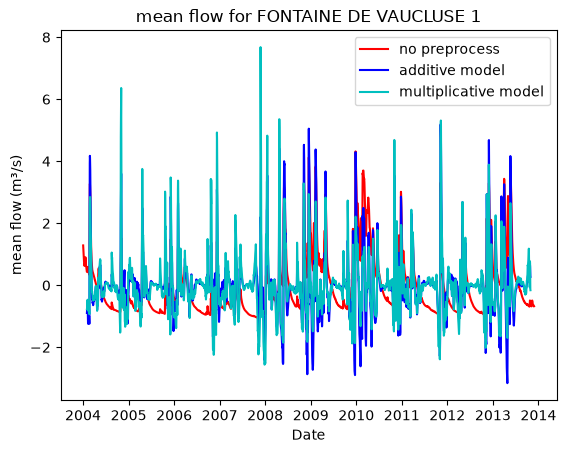

In [2]:
fdv1 = pd.read_csv('donnees/rivers_02-13.csv', sep=';', parse_dates=['date'])
fdv1 = fdv1[(fdv1['city']=='FONTAINE DE VAUCLUSE 1') & (fdv1['date'] > '2004-01-01')]
mean_flow_fdv1 = fdv1['mean_flow']
river_flow = fun.normalize_series(mean_flow_fdv1)


deseason_mean_flow_fdv1 = fun.deseason_add(mean_flow_fdv1, 1)
detrend_mean_flow_fdv1 = fun.detrend_add(deseason_mean_flow_fdv1)
normalize_mean_flow_fdv1_a = fun.normalize_series(detrend_mean_flow_fdv1)
river_flow_a = normalize_mean_flow_fdv1_a
plt.figure()
plt.plot(fdv1['date'], fun.normalize_series(mean_flow_fdv1), label = 'no preprocess', color='r')
plt.plot(fdv1['date'], normalize_mean_flow_fdv1_a, label = 'additive model', color='b')


deseason_mean_flow_fdv1 = fun.deseason_mult(mean_flow_fdv1, 1)
detrend_mean_flow_fdv1 = fun.detrend_mult(deseason_mean_flow_fdv1)
normalize_mean_flow_fdv1_m = fun.normalize_series(detrend_mean_flow_fdv1)
river_flow_m = normalize_mean_flow_fdv1_m
plt.plot(fdv1['date'], normalize_mean_flow_fdv1_m, label = 'multiplicative model', color='c')


plt.title('mean flow for FONTAINE DE VAUCLUSE 1')
plt.xlabel('Date')
plt.ylabel('mean flow (m³/s)')
plt.legend()

    Precipitation

/home/eulalie/Documents/eulalie/etude/cesure/taiwan/travail/NTU_ecoinformatic/mywork/import_function.py:58: RuntimeWarning: invalid value encountered in scalar divide
  deseasoned.append(series[j]/mean_season_index[position_idx[j]])


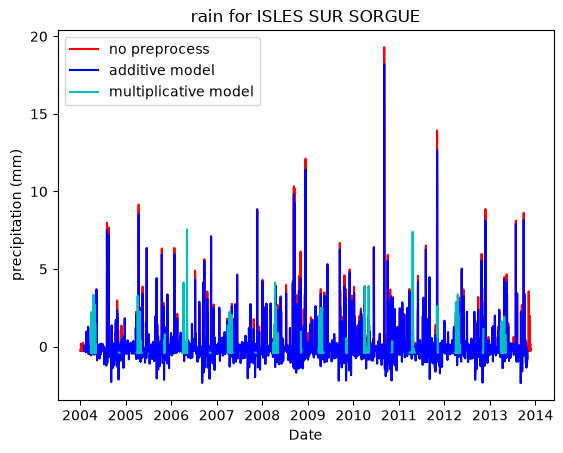

In [3]:
meteo = pd.read_csv('donnees/meteo_02-13.csv', sep = ';', parse_dates=['date'])
meteo = meteo[(meteo['city'] == 'ISLE SUR SORGUE') & (meteo['date'] > '2004-01-01')]
rain = meteo['precipitation']

rain_ = fun.normalize_series(rain)

deseason_rain= fun.deseason_add(rain, 1)
detrend_rain = fun.detrend_add(deseason_rain)
normalize_rain = fun.normalize_series(detrend_rain)
rain_a = normalize_rain
plt.figure()
plt.plot(meteo['date'], rain_, label = 'no preprocess', color = 'r')
plt.plot(meteo['date'], rain_a, label = 'additive model', color ='b')


deseason_rain= fun.deseason_mult(rain, 1)
detrend_rain = fun.detrend_mult(deseason_rain)
normalize_rain = fun.normalize_series(detrend_rain)
rain_m = normalize_rain
plt.plot(meteo['date'], rain_m, label = 'multiplicative model', color ='c')

plt.title('rain for ISLES SUR SORGUE')
plt.xlabel('Date')
plt.ylabel('precipitation (mm)')
plt.legend()

    Groundwater

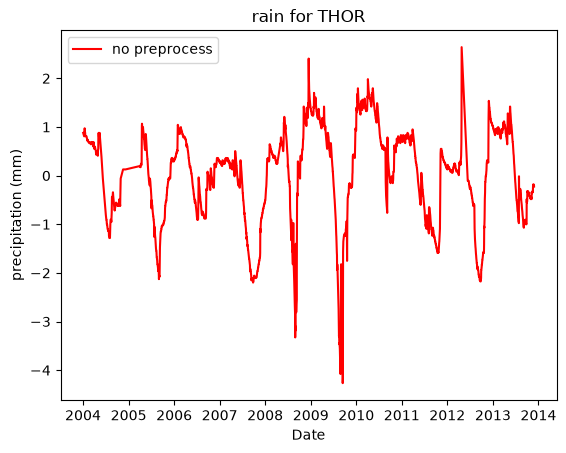

In [4]:
ground_water = pd.read_csv('donnees/groundwater_02-13.csv', sep=';', parse_dates = ['date'])
ground_water = ground_water[(ground_water['city']=='THOR') & (ground_water['date'] > '2004-01-01')]
depth = ground_water['NGF_depth']
depth = fun.normalize_series(depth)

plt.figure()
plt.plot(ground_water['date'], depth, label = 'no preprocess', color = 'r')
plt.title('rain for THOR')
plt.xlabel('Date')
plt.ylabel('precipitation (mm)')
plt.legend()

### Simplex algorithm

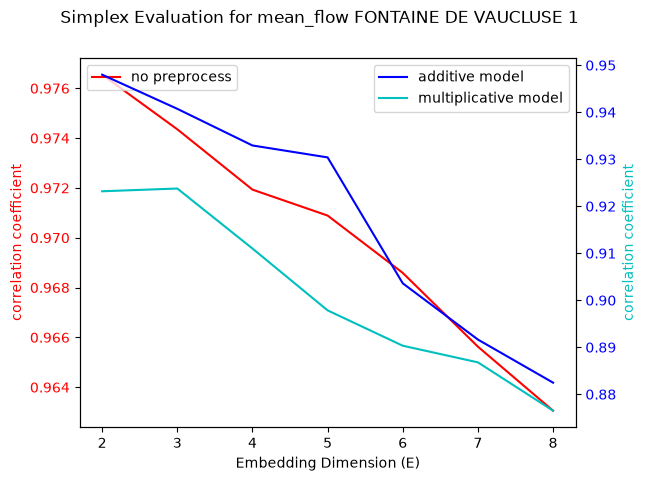

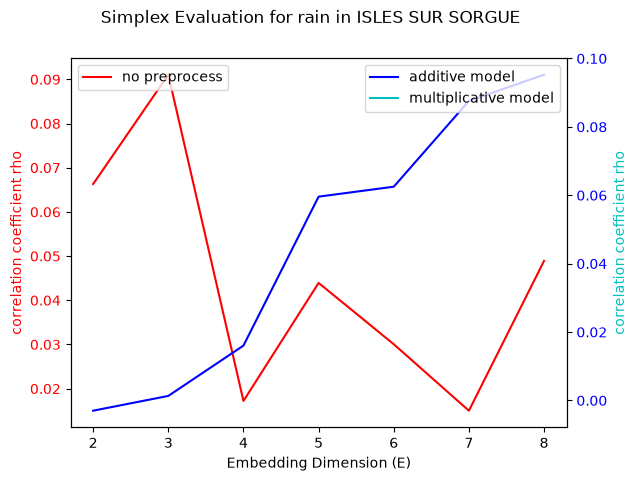

In [5]:
result = fun.evaluate_dimension(fun.normalize_series(mean_flow_fdv1))
result_a = fun.evaluate_dimension(normalize_mean_flow_fdv1_a)
result_m = fun.evaluate_dimension(normalize_mean_flow_fdv1_m)

fig, ax1 = plt.subplots()
ax2 = ax1.twinx()
ax1.plot(result['E'], result['rho'], label = 'no preprocess', color='r')
ax2.plot(result_a['E'], result_a['rho'], label = 'additive model', color = 'b')
ax2.plot(result_m['E'], result_m['rho'], label = 'multiplicative model', color='c')
fig.suptitle('Simplex Evaluation for mean_flow FONTAINE DE VAUCLUSE 1')
ax1.set_xlabel('Embedding Dimension (E)')
ax1.set_ylabel('correlation coefficient', color='r')
ax2.set_ylabel('correlation coefficient', color='c')
ax1.tick_params(axis='y', labelcolor='r')
ax2.tick_params(axis='y', labelcolor='b')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

result_rain = fun.evaluate_dimension(rain_)
result_rain_a = fun.evaluate_dimension(rain_a)
result_rain_m = fun.evaluate_dimension(rain_m)

fig, ax1 = plt.subplots()
ax2 = ax1.twinx()
ax1.plot(result_rain['E'], result_rain['rho'], label = 'no preprocess', color='r')
ax2.plot(result_rain_a['E'], result_rain_a['rho'], label = 'additive model', color = 'b')
ax2.plot(result_rain_m['E'], result_rain_m['rho'], label = 'multiplicative model', color='c')
fig.suptitle('Simplex Evaluation for rain in ISLES SUR SORGUE')
ax1.set_xlabel('Embedding Dimension (E)')
ax1.set_ylabel('correlation coefficient rho', color='r')
ax2.set_ylabel('correlation coefficient rho', color='c')
ax1.tick_params(axis='y', labelcolor='r')
ax2.tick_params(axis='y', labelcolor='b')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')


### S-MAP Algorithm

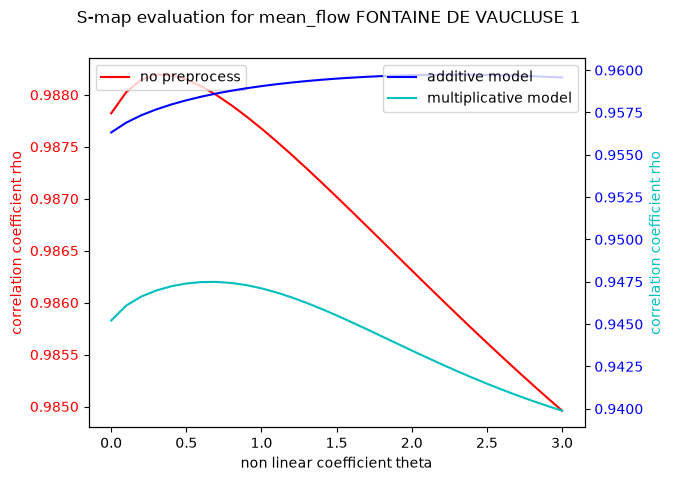

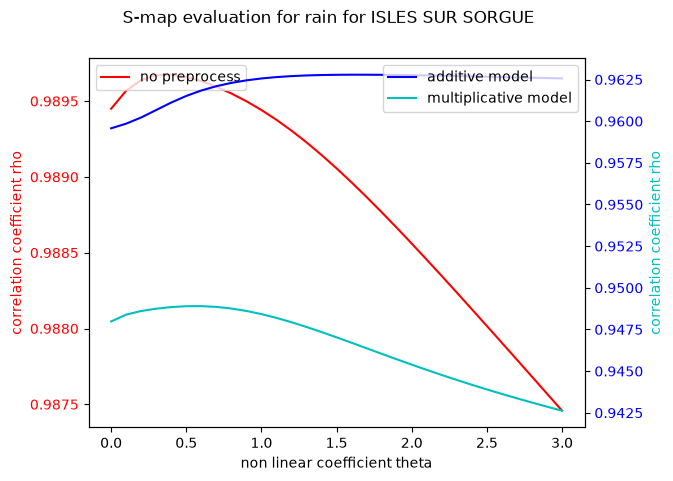

In [6]:
s_map = fun.run_smap(river_flow, 2)
s_map_m = fun.run_smap(river_flow_m, 3)
s_map_a = fun.run_smap(river_flow_a, 2)

fig, ax1 = plt.subplots()
ax2 = ax1.twinx()
ax1.plot(s_map['theta'], s_map['rho'], label = 'no preprocess', color='r')
ax2.plot(s_map_a['theta'], s_map_a['rho'], label = 'additive model', color='b')
ax2.plot(s_map_m['theta'], s_map_m['rho'], label = 'multiplicative model', color='c')
fig.suptitle('S-map evaluation for mean_flow FONTAINE DE VAUCLUSE 1')
ax1.set_xlabel('non linear coefficient theta')
ax1.set_ylabel('correlation coefficient rho', color='r')
ax2.set_ylabel('correlation coefficient rho', color='c')
ax1.tick_params(axis='y', labelcolor='r')
ax2.tick_params(axis='y', labelcolor='b')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

s_map_rain = fun.run_smap(river_flow, 3)
s_map_rain_m = fun.run_smap(river_flow_m, 6)
s_map_rain_a = fun.run_smap(river_flow_a, 5)

fig, ax1 = plt.subplots()
ax2 = ax1.twinx()
ax1.plot(s_map_rain['theta'], s_map_rain['rho'], label = 'no preprocess', color='r')
ax2.plot(s_map_rain_a['theta'], s_map_rain_a['rho'], label = 'additive model', color='b')
ax2.plot(s_map_rain_m['theta'], s_map_rain_m['rho'], label = 'multiplicative model', color='c')
fig.suptitle('S-map evaluation for rain for ISLES SUR SORGUE')
ax1.set_xlabel('non linear coefficient theta')
ax1.set_ylabel('correlation coefficient rho', color='r')
ax2.set_ylabel('correlation coefficient rho', color='c')
ax1.tick_params(axis='y', labelcolor='r')
ax2.tick_params(axis='y', labelcolor='b')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

## CCM Algorithm (only non preprocess data are used here)

My issue in this part is that the code is veryyyy long to run, each ccm takes forever... I tried to switch to a pyEDM version based on c++ to reduce the computation time but it doesn't seem to get better.
Maybe I am not using the right parameteres when runnin the function ? 

    Precipitation -> streamflow

(0.0, 1.0)

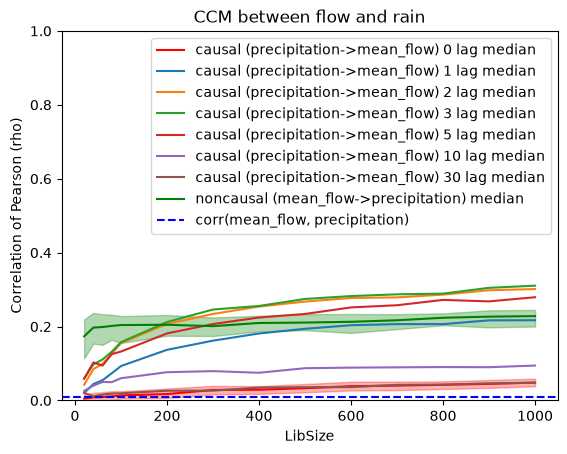

In [8]:
df = (
    pd.merge(
        meteo[['date', 'precipitation']].dropna(),
        fdv1[['date', 'mean_flow']].dropna(),
        on='date',
        how='inner'
    )
    .sort_values('date')
    .reset_index(drop=True)
)

df = df[['date', 'precipitation', 'mean_flow']].dropna().reset_index(drop=True)

E_best_causal = fun.find_best_E(df, 'mean_flow', 'precipitation')
E_best_noncausal = fun.find_best_E(df, 'precipitation', 'mean_flow')

libs = list(range(20, 81, 20)) + list(range(100, 1001, 100)) + list(range(1100, 3001, 250))

causal = fun.run_ccm_bootstrap(df, 'mean_flow', 'precipitation', E_best_causal, libs=libs)
non_causal = fun.run_ccm_bootstrap(df, 'precipitation', 'mean_flow', E_best_noncausal, libs=libs)


final_causal0 = fun.final_ccm(df, 'mean_flow', 'precipitation', libs=libs, Tp=0)
final_causal1 = fun.final_ccm(df, 'mean_flow', 'precipitation', libs=libs, Tp=-1)
final_causal2 = fun.final_ccm(df, 'mean_flow', 'precipitation', libs=libs, Tp=-2)
final_causal3 = fun.final_ccm(df, 'mean_flow', 'precipitation', libs=libs, Tp=-3)
final_causal5 = fun.final_ccm(df, 'mean_flow', 'precipitation', libs=libs, Tp=-5)
final_causal10 = fun.final_ccm(df, 'mean_flow', 'precipitation', libs=libs, Tp=-10)
final_causal30 = fun.final_ccm(df, 'mean_flow', 'precipitation', libs=libs, Tp=-30)
final_noncausal = fun.final_ccm(df, 'precipitation', 'mean_flow', libs=libs)


stat_causal0 = final_causal0[0]
stat_causal1 = final_causal1[0]
stat_causal2 = final_causal2[0]
stat_causal3 = final_causal3[0]
stat_causal5 = final_causal5[0]
stat_causal10 = final_causal10[0]
stat_causal30 = final_causal30[0]
stat_noncausal = final_noncausal[0]

libsize = stat_causal0.index

corr0 = df['mean_flow'].corr(df['precipitation'])

plt.figure()
plt.plot(libsize, stat_causal0[0.5], color='r', label= 'causal (precipitation->mean_flow) 0 lag' + " median")
plt.fill_between(libsize, stat_causal0[0.25], stat_causal0[0.75], color='r', alpha=0.3)
plt.plot(libsize, stat_causal1[0.5], label= 'causal (precipitation->mean_flow) 1 lag' + " median")
plt.plot(libsize, stat_causal2[0.5], label= 'causal (precipitation->mean_flow) 2 lag' + " median")
plt.plot(libsize, stat_causal3[0.5], label= 'causal (precipitation->mean_flow) 3 lag' + " median")
plt.plot(libsize, stat_causal5[0.5], label= 'causal (precipitation->mean_flow) 5 lag' + " median")
plt.plot(libsize, stat_causal10[0.5],label= 'causal (precipitation->mean_flow) 10 lag' + " median")
plt.plot(libsize, stat_causal30[0.5],label= 'causal (precipitation->mean_flow) 30 lag' + " median")
plt.plot(libsize, stat_noncausal[0.5], color='g', label= 'noncausal (mean_flow->precipitation)' + " median")
plt.fill_between(libsize, stat_noncausal[0.25], stat_noncausal[0.75], color='g', alpha=0.3)
plt.axhline(corr0, color='b', linestyle='--', label=f"corr(mean_flow, precipitation)")
plt.title('CCM between flow and rain')
plt.xlabel('LibSize')
plt.ylabel('Correlation of Pearson (rho)')
plt.legend()
plt.ylim(0,1)

## this is very strange because it seems that there is a causality mean_flow --> precipitation instead of precipitation --> mean_flow
# even though we are using different kind of preprocessing
# an explanation could be : artefact/error in the code, lack in the data (particularly a lot of 0 in precipitation data) or delay between precipitation and variation of mean_flow
# so I can also try to implement delay to but I am not sure how to do it --> need to read the last article

#with 3 days lag dand without preprocess result seems statisfying but we now need to quantify thsi result thanks to surrogate and pvalue

![title](img/ccm_lag.png)

    Groundwater <-> streamflow

In [ ]:
df = pd.merge(fdv1[['date', 'mean_flow']], ground_water[['date', 'NGF_depth']], on='date', how='inner').sort_values('date').reset_index(drop=True)
df = df[['date', 'mean_flow', 'NGF_depth']].dropna().reset_index(drop=True)
libs = list(range(20, 81, 20)) + list(range(100, 1001, 100)) + list(range(1100, 3001, 250))

E_best_infiltration = fun.find_best_E(df, 'NGF_depth', 'mean_flow')
E_best_saturation = fun.find_best_E(df, 'mean_flow', 'NGF_depth')

infiltration = fun.run_ccm_bootstrap(df, 'NGF_depth', 'mean_flow', E_best_infiltration, libs=libs)
saturation = fun.run_ccm_bootstrap(df, 'mean_flow', 'NGF_depth', E_best_saturation, libs=libs)


final_infiltration0 = fun.final_ccm(df, 'NGF_depth', 'mean_flow', libs=libs, Tp=0)
final_infiltration1 = fun.final_ccm(df, 'NGF_depth', 'mean_flow', libs=libs, Tp=-1)
final_infiltration3 = fun.final_ccm(df, 'NGF_depth', 'mean_flow', libs=libs, Tp=-3)
final_infiltration5 = fun.final_ccm(df, 'NGF_depth', 'mean_flow', libs=libs, Tp=-5)
final_infiltration10 = fun.final_ccm(df, 'NGF_depth', 'mean_flow', libs=libs, Tp=-10)
final_infiltration30 = fun.final_ccm(df, 'NGF_depth', 'mean_flow', libs=libs, Tp=-30)

final_saturation0 = fun.final_ccm(df, 'mean_flow', 'NGF_depth', libs=libs, Tp=0)
final_saturation1 = fun.final_ccm(df, 'mean_flow', 'NGF_depth', libs=libs, Tp=-1)
final_saturation3 = fun.final_ccm(df, 'mean_flow', 'NGF_depth', libs=libs, Tp=-3)
final_saturation5 = fun.final_ccm(df, 'mean_flow', 'NGF_depth', libs=libs, Tp=-5)
final_saturation10 = fun.final_ccm(df, 'mean_flow', 'NGF_depth', libs=libs, Tp=10)
final_saturation30 = fun.final_ccm(df, 'mean_flow', 'NGF_depth', libs=libs, Tp=30)


stat_infiltration0 = final_infiltration0[0]
stat_infiltration1 = final_infiltration1[0]
stat_infiltration3 = final_infiltration3[0]
stat_infiltration5 = final_infiltration5[0]
stat_infiltration10 = final_infiltration10[0]
stat_infiltration30 = final_infiltration30[0]

stat_saturation0 = final_saturation0[0]
stat_saturation1 = final_saturation1[0]
stat_saturation3 = final_saturation3[0]
stat_saturation5 = final_saturation5[0]
stat_saturation10 = final_saturation10[0]
stat_saturation30 = final_saturation30[0]

libsize = stat_infiltration0.index

corr0 = df['mean_flow'].corr(df['NGF_depth'])

plt.figure()
plt.plot(libsize, stat_infiltration0[0.5], color='r', label= 'causal (mean_flow->ground_water height) 0 lag' + " median")
plt.plot(libsize, stat_infiltration1[0.5], label= 'causal (mean_flow->ground_water height) 1 lag' + " median")
plt.plot(libsize, stat_infiltration3[0.5], label= 'causal (mean_flow->ground_water height) 3 lag' + " median")
plt.plot(libsize, stat_infiltration5[0.5], label= 'causal (mean_flow->ground_water height) 5 lag' + " median")
plt.plot(libsize, stat_infiltration10[0.5],label= 'causal (mean_flow->ground_water height) 10 lag' + " median")
plt.plot(libsize, stat_infiltration30[0.5],label= 'causal (mean_flow->ground_water height) 30 lag' + " median")
plt.axhline(corr0, color='b', linestyle='--', label=f"corr(mean_flow, precipitation)")
plt.title('CCM between river flow -> ground water')
plt.xlabel('LibSize')
plt.ylabel('Correlation of Pearson (rho)')
plt.legend()
plt.ylim(0,1)


plt.figure()
plt.plot(libsize, stat_saturation0[0.5], color='r', label= 'causal (groundwater height -> mean flow) 0 lag' + " median")
plt.plot(libsize, stat_saturation1[0.5], label= 'causal (groundwater height -> mean flow) 1 lag' + " median")
plt.plot(libsize, stat_saturation3[0.5], label= 'causal (groundwater height -> mean flow) 3 lag' + " median")
plt.plot(libsize, stat_saturation5[0.5], label= 'causal (groundwater height -> mean flow) 5 lag' + " median")
plt.plot(libsize, stat_saturation10[0.5],label= 'causal (groundwater height -> mean flow) 10 lag' + " median")
plt.plot(libsize, stat_saturation30[0.5],label= 'causal (groundwater height -> mean flow) 30 lag' + " median")
plt.axhline(corr0, color='b', linestyle='--', label=f"corr(mean_flow, precipitation)")
plt.title('CCM between groundwater -> river flow')
plt.xlabel('LibSize')
plt.ylabel('Correlation of Pearson (rho)')
plt.legend()
plt.ylim(0,1)

## Surrogate : this is where the trouble begins ...

Again the code is very very long to run, I tried to parallelized some of the ccm in the surrogate function but it's not very satisfying.

$\\$ 

The main issue however is that the result is TOTALLY RANDOM : one time the pvalue is 0.02 and the time after it's 0.3. It doesn't make any sense ! I tried to increase the number of surrogate but it still has this very weird behaviour... I don't know if this is due to some problems in my code (error in computing the pvalue (?)) or in my data (could be data because I am in a part of the world pretty dry with very few rain (?) or maybe just artefact in it (?)).

    Precipitation -> stream flow

In [ ]:
df = (
    pd.merge(
        meteo[['date', 'precipitation']].dropna(),
        fdv1[['date', 'mean_flow']].dropna(),
        on='date',
        how='inner'
    )
    .sort_values('date')
    .reset_index(drop=True)
)

df = df[['date', 'precipitation', 'mean_flow']].dropna().reset_index(drop=True)

libs = list(range(20, 81, 20)) + list(range(100, 1001, 100)) + list(range(1100, 3001, 250))

final_causal = fun.final_ccm(df, 'mean_flow', 'precipitation', libs=libs, Tp=-3)
final_noncausal = fun.final_ccm(df, 'precipitation', 'mean_flow', libs=libs, Tp=0)

stat_causal = final_causal[0]
total_causal = stat_causal[0.5].iloc[-1]
stat_noncausal = final_noncausal[0]
total_noncausal = stat_noncausal[0.5].iloc[-1]
libsize = stat_causal.index

lag_mean_flow = pd.Series(list(df['mean_flow'])+ [None,None,None])
lag_precipitation = pd.Series([None,None,None]+list(df['precipitation']))
corr0 = lag_mean_flow.corr(lag_precipitation)

z1 = np.arctanh(corr0)
z2 = np.arctanh(total_causal)
n = len(df[['mean_flow', 'precipitation']].dropna()) - 3
zobs = (z1-z2) / np.sqrt( 2 / (n-3) )

pval = 2 * stats.norm.cdf(-abs(zobs))


surr_causal = fun.surrogate_fast(df, 'mean_flow', 'precipitation', comparaison = total_causal, libs=libs, num=20, Tp=-3)

pvalue_causal = surr_causal[2]

surresume_causal = surr_causal[1]

plt.figure(figsize=(12, 8))
plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 13,
    "legend.fontsize": 11
})

plt.plot(libsize, stat_causal[0.5], color='r', label='causal (precipitation->mean_flow) 3 lag median')
plt.fill_between(libsize, stat_causal[0.25], stat_causal[0.75], color='r', alpha=0.3)

plt.plot(libsize, stat_noncausal[0.5], color='g', label='noncausal (mean_flow->precipitation) no lag median')
plt.fill_between(libsize, stat_noncausal[0.25], stat_noncausal[0.75], color='g', alpha=0.3)

plt.axhline(corr0, color='b', linestyle='--', label=f"corr(mean_flow, precipitation)")

# boxplots à droite, plus grands
plt.boxplot(
    surr_causal[0],
    positions=[len(libsize)],
    widths=4.0,
    patch_artist=True,
    boxprops=dict(facecolor='red', alpha=0.8),
    medianprops=dict(color='black', linewidth=2),
    whiskerprops=dict(color='black', linewidth=1.5),
    capprops=dict(color='black', linewidth=1.5)
)

plt.scatter(2.0, total_causal, color='red', marker='X', s=180, zorder=3)
plt.text(
    2.25,
    total_causal,
    f"pvalue = {pvalue_causal:.4f}",
    va='bottom',
    fontsize=12,
    color='black'
)

plt.title(f'CCM between flow and rain being (without preprocess with lag) Fisher Z comparison for causal relation: Zscore = {zobs}, pvalue = {pval}', fontsize=15)
plt.xlabel('LibSize', fontsize=13)
plt.ylabel('Correlation of Pearson (rho)', fontsize=13)
plt.legend(fontsize=11)
plt.ylim(0, 1)
plt.tight_layout()

![title](img/link_r-sf_200.png)

    Groundwater <-> stream flow

In [ ]:
df = pd.merge(fdv1[['date', 'mean_flow']], ground_water['date', 'NGF_depth'], on='date', how='inner').sort_values('date').reset_index(drop=True)
df = df[['date', 'mean_flow', 'NGF_depth']].dropna().reset_index(drop=True)

infiltration = fun.final_ccm(df, 'NGF_depth', 'mean_flow', libs=libs, Tp=0)
saturation = fun.final_ccm(df, 'mean_flow', 'NGF_depth', libs=libs, Tp=0)

stat_infiltration = infiltration[0]
total_infiltration = stat_infiltration[0.5].iloc[-1]
stat_saturation = saturation[0]
total_saturation = stat_saturation[0.5].iloc[-1]
libsize = stat_infiltration.index

corr0 = df['NGF_depth'].corr(df['mean_flow'])

z1 = np.arctanh(corr0)
z2 = np.arctanh(total_infiltration)
n = len(df[['mean_flow', 'NGF_depth']].dropna())
zobs = (z1-z2) / np.sqrt( 2 / (n-3) )

pval = 2 * stats.norm.cdf(-abs(zobs))


surr_infiltration = fun.surrogate_fast(df, 'NGF_depth', 'mean_flow', comparaison = total_infiltration, libs=libs, num=20, Tp=-3)
surr_saturation = fun.surrogate_fast(df, 'mean_flow', 'NGF_depth', comparaison = total_saturation, libs=libs, num=20, Tp=0) #200 is better but too long

pvalue_infiltration = surr_infiltration[2]
pvalue_saturation = surr_saturation[2]

surresume_infiltration = surr_infiltration[1]
surresume_saturation = surr_saturation[1]

plt.figure(figsize=(12, 8))
plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 13,
    "legend.fontsize": 11
})

plt.plot(libsize, stat_infiltration[0.5], color='r', label='infiltration (mean_flow->groundwater depth) no lag median')
plt.fill_between(libsize, stat_infiltration[0.25], stat_infiltration[0.75], color='r', alpha=0.3)

plt.plot(libsize, stat_saturation[0.5], color='g', label='saturation (groundwater depth->mean_flow) no lag median')
plt.fill_between(libsize, stat_saturation[0.25], stat_saturation[0.75], color='g', alpha=0.3)

plt.axhline(corr0, color='b', linestyle='--', label=f"corr(mean_flow, NGF_depth)")

# boxplots à droite, plus grands
plt.boxplot(
    surr_infiltration[0],
    positions=[len(libsize)],
    widths=4.0,
    patch_artist=True,
    boxprops=dict(facecolor='red', alpha=0.8),
    medianprops=dict(color='black', linewidth=2),
    whiskerprops=dict(color='black', linewidth=1.5),
    capprops=dict(color='black', linewidth=1.5)
)

plt.scatter(2.0, total_infiltration, color='red', marker='X', s=180, zorder=3)
plt.text(
    2.25,
    total_infiltration,
    f"pvalue = {pvalue_infiltration:.4f}",
    va='bottom',
    fontsize=12,
    color='black'
)

plt.boxplot(
    surr_saturation[0],
    positions=[len(libsize)],
    widths=4.0,
    patch_artist=True,
    boxprops=dict(facecolor='green', alpha=0.8),
    medianprops=dict(color='black', linewidth=2),
    whiskerprops=dict(color='black', linewidth=1.5),
    capprops=dict(color='black', linewidth=1.5)
)

plt.scatter(2.8, total_saturation, color='green', marker='X', s=180, zorder=3)
plt.text(
    3.05,
    total_saturation,
    f"pvalue = {pvalue_saturation:.4f}",
    va='bottom',
    fontsize=12,
    color='black'
)

plt.title(f'CCM between groundwater and flow (without preprocess with lag) Fisher Z comparison for causal relation: Zscore = {zobs}, pvalue = {pval}', fontsize=15)
plt.xlabel('LibSize', fontsize=13)
plt.ylabel('Correlation of Pearson (rho)', fontsize=13)
plt.legend(fontsize=11)
plt.ylim(0, 1)
plt.tight_layout()


![title](img/link_gw-sf_200.png)

![title](img/link_gw-sf.png)

## Different type of embedding for prediction

In [ ]:
df = pd.merge(fdv1[['date', 'mean_flow']], meteo['date', 'precipitation'], on='date', how='inner').sort_values('date').reset_index(drop=True)
df = pd.merge(df, ground_water['date', 'NGF_depth'], on='date', how='inner').sort_values('date').reset_index(drop=True)
df = df[['date', 'mean_flow', 'NGF_depth', 'lag_precipitation']].dropna().reset_index(drop=True)

df = df.copy()
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df = df.dropna(subset=['date']).sort_values('date').reset_index(drop=True)
df['date'] = df['date'].dt.strftime('%Y-%m-%d')


    Univariate

In [ ]:
lib_start = 1
lib_end = len(df) // 2
pred_start = lib_end + 1
pred_end = len(df)

pred_mean_flow, bestE = fun.simplex_prediction(df, 'mean_flow', 'mean_flow', lib_range=f'{lib_start} {lib_end}', pred_range=f'{pred_start} {pred_end}')
E_meanflow = fun.evaluate_dimension(df['mean_flow'], lib=f'{lib_start} {lib_end}', pred=f'{pred_start} {pred_end}')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(E_meanflow['E'], E_meanflow['rho'], marker='o')
axes[0].set_xlabel("Embedding dimension E")
axes[0].set_ylabel("Correlation rho")
axes[0].set_title("Best embedding dimension based on correlation")
axes[0].grid(True)

pred_mean_flow = pred_mean_flow.dropna(subset=["Predictions", "Observations"])

obs_valid = pred_mean_flow['Observations'].values
pred_valid = pred_mean_flow['Predictions'].values
rho = np.corrcoef(obs_valid, pred_valid)[0, 1]    

axes[1].scatter(obs_valid, pred_valid, alpha=0.6)
axes[1].plot([obs_valid.min(), obs_valid.max()], [obs_valid.min(), obs_valid.max()], 'r--')
axes[1].set_xlabel("Observed")
axes[1].set_ylabel("Prediction")
axes[1].set_title(f"Univariate simplex projection (E={bestE} and rho={rho})")
axes[1].grid(True)


    Multivariate

In [ ]:
pred_mean_flow, bestE = fun.simplex_prediction(df, 'mean_flow NGF_depth precipitation', 'mean_flow', lib_range=f'{lib_start} {lib_end}', pred_range = f'{pred_start} {pred_end}')
    
plt.figure()

pred_mean_flow = pred_mean_flow.dropna(subset=["Predictions", "Observations"])

obs_valid = pred_mean_flow['Observations'].values
pred_valid = pred_mean_flow['Predictions'].values
rho = np.corrcoef(obs_valid, pred_valid)[0, 1]    

plt.scatter(obs_valid, pred_valid, alpha=0.6)
plt.plot([obs_valid.min(), obs_valid.max()], [obs_valid.min(), obs_valid.max()], 'r--')
plt.xlabel("Observed")
plt.ylabel("Prediction")
plt.title(f"Multivariate simplex projection (E={bestE} and rho={rho})")
plt.grid(True)

    Multiview

In [ ]:
pred_mean_flow = fun.Multiview(df, 'mean_flow NGF_depth precipitation', 'mean_flow', lib=f'{lib_start} {lib_end}', pred = f'{pred_start} {pred_end}', E=bestE, Tp=0)['Predictions']

plt.figure()

pred_mean_flow = pred_mean_flow.dropna(subset=["Predictions", "Observations"])

obs_valid = pred_mean_flow['Observations'].values
pred_valid = pred_mean_flow['Predictions'].values
rho = np.corrcoef(obs_valid, pred_valid)[0, 1]    

plt.scatter(obs_valid, pred_valid, alpha=0.6)
plt.plot([obs_valid.min(), obs_valid.max()], [obs_valid.min(), obs_valid.max()], 'r--')
plt.xlabel("Observed")
plt.ylabel("Prediction")
plt.title(f"Multiview simplex projection (E={bestE} and rho={rho})")
plt.grid(True)

## Interaction strenght (where the trouble continues)

The intercation is very very very very weak (10e-12): it is not an issue but it seems strange to me that this is the case for all of them even for simple causality link such as the link between river and precipitation. An explanation could be the fact that my data of weather, river, and groundwater are too far from each other geographically speaking. $\\$
A way to confirm this idea would be to test the code on even more simple relationship such as (rain<->temperature) to see if the correlation increase and to test the code on other data from other region of the world. I have already downloaded new datasets but still haven't time to test those two propositions.

In [ ]:
res_meanflow, best_theta = fun.Smap_prediction(df, "mean_flow precipitation NGF_depth", 'mean_flow', lib=f'{lib_start} {lib_end}', pred = f'{pred_start} {pred_end}')
pred_mean_flow = res_meanflow['predictions']

plt.figure()

pred_mean_flow = pred_mean_flow.dropna(subset=["Predictions", "Observations"])

obs_valid = pred_mean_flow['Observations'].values
pred_valid = pred_mean_flow['Predictions'].values
rho = np.corrcoef(obs_valid, pred_valid)[0, 1]    

plt.scatter(obs_valid, pred_valid, alpha=0.6)
plt.plot([obs_valid.min(), obs_valid.max()], [obs_valid.min(), obs_valid.max()], 'r--')
plt.xlabel("Observed")
plt.ylabel("Prediction")
plt.title(f"Multiview simplex projection (E={bestE} and rho={rho})")
plt.grid(True)

coefficients = res_meanflow['coefficients']

time_range = range(min(200, len(coefficients)))  # limit to 200 time steps
plt.figure(figsize=(10, 5))
plt.plot(time_range, coefficients.loc[time_range, '∂mean_flow/∂precipitation'], label='∂mean_flow/∂precipitation', color="royalblue", linewidth=2)
plt.plot(time_range, coefficients.loc[time_range, '∂mean_flow/∂NGF_depth'], label='∂mean_flow/∂NGF_depth', color="red", linewidth=2)
plt.axhline(0, color="black", linestyle="dashed", linewidth=0.8)
plt.xlabel("Time")
plt.ylabel("Interaction strength")
plt.title("S-map Coefficients (Time-varying interaction strengths)")
plt.legend()
plt.grid(True)
plt.tight_layout()

![title](img/interaction_strength.png)

## Exploration

(for future development, not interesting for the moment)

### Parameter exploration

In [ ]:
E = fun.find_best_E(df, 'mean_flow', 'mean_flow') 

embed = np.column_stack([
    df["mean_flow"].values[i:len(df) - E + i + 1] for i in range(E)
])
Rain_trim = df["precipitation"].values[E - 1:]
block0 = np.column_stack([embed, Rain_trim])
col_names = [f"mean_flow_t_{i}" for i in reversed(range(E))] + ["Rain_t"]

# --- Scenarios: R up/down ---
block_inc0 = np.column_stack([embed, Rain_trim + 10])
block_dec0 = np.column_stack([embed, Rain_trim - 10])

df_block0 = pd.DataFrame(block0, columns=col_names)
pred_nochange = Simplex(df_block0, lib=f"1 {len(block0)}", pred=f"1 {len(block0)}",
                        columns=col_names, target=col_names[0], E=E, verbose=False)

# --- Scenario predictions ---
n0 = len(block0)
block_inc_all = np.vstack([block0, block_inc0])
block_dec_all = np.vstack([block0, block_dec0])
df_block_inc = pd.DataFrame(block_inc_all, columns=col_names)
df_block_dec = pd.DataFrame(block_dec_all, columns=col_names)

step = 100
predictions_inc, predictions_dec = [], []

for start_pred in range(n0 + 1, n0 + len(block_inc0) + 1, step):
    end_pred = min(start_pred + step - 1, n0 + len(block_inc0))

    res_inc = Simplex(df_block_inc, lib=f"1 {n0}", pred=f"{start_pred} {end_pred}",
                    columns=col_names, target=col_names[0], E=E, verbose=False)
    predictions_inc.append(res_inc["Predictions"].dropna())

    res_dec = Simplex(df_block_dec, lib=f"1 {n0}", pred=f"{start_pred} {end_pred}",
                    columns=col_names, target=col_names[0], E=E, verbose=False)
    predictions_dec.append(res_dec["Predictions"].dropna())

pred_increase = pd.concat(predictions_inc)
pred_decrease = pd.concat(predictions_dec)

# --- Plot ---
trange = range(50)
plt.figure(figsize=(10, 6))
plt.plot(pred_nochange.iloc[trange]["Observations"].values, label="Observed", color="black", linewidth=2)
plt.scatter(trange, pred_nochange.iloc[trange]["Predictions"].values, label="Predicted", color="black", marker='o')
plt.scatter(trange, pred_increase.values[:len(trange)], label="R Increased", color="red", marker='^')
plt.scatter(trange, pred_decrease.values[:len(trange)], label="R Decreased", color="blue", marker='v')
plt.xlabel("Time")
plt.ylabel("Normalized C1")
plt.title("Scenario Exploration on C1 (ODE, tau=5)")
plt.legend()
plt.grid(True)
plt.tight_layout()

### Tipping point (NLA Algorithm)